Loaded data: 10000 samples, range=[-2.239, 1.363], mean=-1.004, std=1.021
Train: (3999, 1), Test: (1999, 1), Sync: 300, Pred: 1699

Grid sizes:
  alpha_min      : 23  (TOP priority)
  spectral_radius: 6  (HIGH)
  fb_scaling     : 4  (HIGH)
  input_scaling  : 3  (HIGH)
  ridge          : 4  (MED)
  seed           : 3  (averaging)
  TOTAL combinations: 19872

RUNNING GRID SEARCH
  [500/19872]  elapsed=79s  ETA=3043s
  [1000/19872]  elapsed=157s  ETA=2968s
  [1500/19872]  elapsed=237s  ETA=2907s
  [2000/19872]  elapsed=321s  ETA=2871s
  [2500/19872]  elapsed=411s  ETA=2853s
  [3000/19872]  elapsed=493s  ETA=2770s
  [3500/19872]  elapsed=577s  ETA=2699s
  [4000/19872]  elapsed=657s  ETA=2607s
  [4500/19872]  elapsed=735s  ETA=2512s
  [5000/19872]  elapsed=813s  ETA=2417s
  [5500/19872]  elapsed=899s  ETA=2349s
  [6000/19872]  elapsed=976s  ETA=2257s
  [6500/19872]  elapsed=1053s  ETA=2166s
  [7000/19872]  elapsed=1130s  ETA=2079s
  [7500/19872]  elapsed=1207s  ETA=1991s
  [8000/19872]  ela

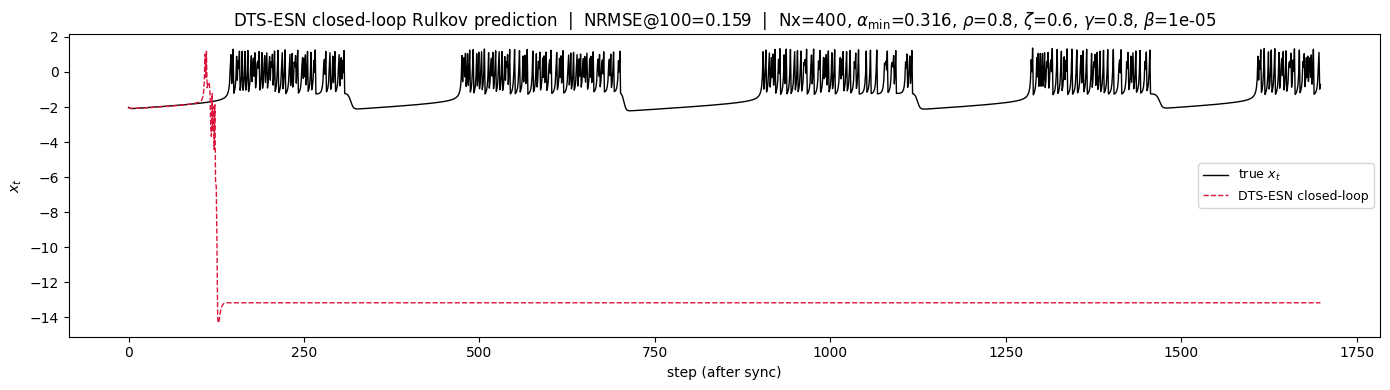

In [8]:
"""
DTS-ESN grid search for closed-loop prediction of the Rulkov map.

Faithful implementation of:
  Tanaka, Matsumori, Yoshida, Aihara,
  "Reservoir computing with diverse timescales for prediction of multiscale
   dynamics", Phys. Rev. Research 4, L032014 (2022).

Data source: user's saved Rulkov CSV (column 0 only -- the fast x variable).
No data generation here.

----------------------------------------------------------------------
Paper's closed-loop equations (Eqs. 1-3, Task 2 / second case of Eq. 3):

    h(t)     = rho*W x(t) + gamma*Win u(t+dt) + zeta*Wfb y(t)
    x(t+dt)  = (I - A) x(t) + A * tanh( h(t) )
    y(t+dt)  = W_out x(t+dt)

with A = diag(alpha_1, ..., alpha_Nx),
     log10(alpha_i) ~ U(log10 a_min, log10 a_max).

----------------------------------------------------------------------
RANKING METRIC -- why NRMSE not valid time here.

The paper uses valid time as its long-term metric, but they compute it on
the SLOW variable y (Rulkov's second component).  With only the FAST x
channel available, pointwise valid time saturates at 0 for almost every
hyperparameter: even a well-tracking closed-loop prediction will exceed
a 0.5 z-std threshold within a few steps because x itself swings by that
much between consecutive spikes.

We therefore rank by SHORT-HORIZON NRMSE in z-scored space over the first
100 steps.  This is continuous, discriminative, and corresponds to the
same underlying goal (how well does the closed loop track truth).  Valid
time is still reported as a diagnostic with a generous threshold.

----------------------------------------------------------------------
PARAMETER PRIORITIES:

  TOP   : alpha_min                  -- the central knob of the paper
  HIGH  : spectral_radius (rho)
  HIGH  : fb_scaling (zeta)
  HIGH  : input_scaling (gamma)
  MED   : ridge (beta)
  LOW   : density (d)                -- fixed at 0.1 per paper
  LOW   : alpha_max                  -- fixed at 1.0 per paper
  FIXED : Nx, train/test lengths, washouts
"""

import itertools
import time
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# User's scaler utilities
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..',)))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)


# ==========================================================
# DTS-ESN
# ==========================================================
class DTSESN:
    """
    Diverse-Timescale ESN with output feedback -- Task 2 closed-loop variant.

    State update (paper Eqs. 1-3):
        h(t)    = rho*W x(t) + gamma*Win u(t+dt) + zeta*Wfb y(t)
        x(t+dt) = (I - A) x(t) + A * tanh( h(t) )
        y(t+dt) = W_out x(t+dt)
    """

    def __init__(self, n_inputs, n_outputs, n_reservoir,
                 alpha_min, alpha_max=1.0,
                 spectral_radius=1.0, input_scaling=0.8, fb_scaling=1.0,
                 density=0.1, ridge=1e-3, seed=42):
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.n_reservoir = int(n_reservoir)
        self.alpha_min = alpha_min
        self.alpha_max = alpha_max
        self.rho = spectral_radius
        self.gamma = input_scaling
        self.zeta = fb_scaling
        self.density = density
        self.ridge = ridge
        self.rng = np.random.default_rng(seed)

        self._build_weights()
        self._build_leaks()
        self.W_out = None
        self.x = np.zeros(self.n_reservoir)

    def _build_weights(self):
        Nx = self.n_reservoir
        W = self.rng.uniform(-1.0, 1.0, size=(Nx, Nx))
        mask = self.rng.uniform(0.0, 1.0, size=(Nx, Nx)) < self.density
        W = W * mask
        eig = np.linalg.eigvals(W)
        sr = float(np.max(np.abs(eig)))
        if sr > 0:
            W = W / sr
        self.W = self.rho * W
        self.W_in = self.rng.uniform(-1.0, 1.0, size=(Nx, self.n_inputs))
        self.W_fb = self.rng.uniform(-1.0, 1.0, size=(Nx, self.n_outputs))

    def _build_leaks(self):
        Nx = self.n_reservoir
        if self.alpha_min == self.alpha_max:
            self.alphas = np.full(Nx, self.alpha_max)
        else:
            log_a = self.rng.uniform(np.log10(self.alpha_min),
                                     np.log10(self.alpha_max), size=Nx)
            self.alphas = 10.0 ** log_a

    def reset(self):
        self.x = np.zeros(self.n_reservoir)

    def _step(self, u, y_fb):
        h = (self.W @ self.x
             + self.gamma * (self.W_in @ np.atleast_1d(u))
             + self.zeta  * (self.W_fb @ np.atleast_1d(y_fb)))
        self.x = (1.0 - self.alphas) * self.x + self.alphas * np.tanh(h)

    def fit(self, U, Y, washout):
        """
        Teacher-forced training.
            U[t] = input at step t, Y[t] = target = input at step t+1.
        Feedback at iteration t uses y_fb = Y[t-1]; at t=0 we use 0.
        """
        T = U.shape[0]
        X = np.zeros((T, self.n_reservoir))
        self.reset()
        y_fb = np.zeros(self.n_outputs)
        for t in range(T):
            self._step(U[t], y_fb)
            X[t] = self.x
            y_fb = Y[t]
        X_use = X[washout:]
        Y_use = Y[washout:]
        A = X_use.T @ X_use + self.ridge * np.eye(self.n_reservoir)
        B = X_use.T @ Y_use
        self.W_out = np.linalg.solve(A, B).T
        return self

    def synchronize(self, U_sync, Y_sync):
        """Teacher-force over a sync window.  Returns last feedback."""
        self.reset()
        y_fb = np.zeros(self.n_outputs)
        for t in range(U_sync.shape[0]):
            self._step(U_sync[t], y_fb)
            y_fb = Y_sync[t]
        return y_fb

    def closed_loop(self, n_steps, u0, y0_fb):
        """Generate n_steps autonomously."""
        preds = np.zeros((n_steps, self.n_outputs))
        u = np.atleast_1d(u0).astype(float).copy()
        y_fb = np.atleast_1d(y0_fb).astype(float).copy()
        for t in range(n_steps):
            self._step(u, y_fb)
            y_hat = self.W_out @ self.x
            preds[t] = y_hat
            u = y_hat.copy()
            y_fb = y_hat.copy()
        return preds


# ==========================================================
# METRICS
# ==========================================================
def short_horizon_nrmse(y_pred, y_true, horizon=100):
    """Primary ranking metric.  NRMSE over first `horizon` steps in z-space."""
    h = min(horizon, len(y_true))
    yp = np.asarray(y_pred[:h]).ravel()
    yt = np.asarray(y_true[:h]).ravel()
    if not np.all(np.isfinite(yp)):
        return np.inf
    rmse = np.sqrt(np.mean((yp - yt) ** 2))
    denom = np.std(yt)
    return rmse / denom if denom > 0 else np.inf


def valid_time(y_pred, y_true, eps):
    """Diagnostic metric.  Use generous eps for fast-spiking signals."""
    yp = np.asarray(y_pred).ravel()
    yt = np.asarray(y_true).ravel()
    n = min(len(yp), len(yt))
    yp, yt = yp[:n], yt[:n]
    if not np.all(np.isfinite(yp)):
        return 0
    err = np.abs(yp - yt)
    over = np.where(err > eps)[0]
    return int(over[0]) if len(over) else n


# ==========================================================
# LOAD USER'S DATA
# ==========================================================
dataset = np.loadtxt('../../../data/chaotic_data/rulkov_map.csv', delimiter=',')
if dataset.ndim == 2:
    dataset = dataset[:, 0]
data = dataset.reshape(-1, 1)

print(f"Loaded data: {data.shape[0]} samples, "
      f"range=[{data.min():.3f}, {data.max():.3f}], "
      f"mean={data.mean():.3f}, std={data.std():.3f}")


# ==========================================================
# DATA SPLIT
# ==========================================================
TRAIN_LEN = 4000
TEST_START = 4000
TEST_LEN = 2000
SYNC_LEN = 300

# Training pairs: predict next step
X_train_raw = data[:TRAIN_LEN - 1]
Y_train_raw = data[1:TRAIN_LEN]

# Test pairs
X_test_raw = data[TEST_START:TEST_START + TEST_LEN - 1]
Y_test_raw = data[TEST_START + 1:TEST_START + TEST_LEN]

# Z-score using TRAIN ONLY
scaler = fit_scaler(X_train_raw, method="zscore")
X_train = transform_array(X_train_raw, scaler)
Y_train = transform_array(Y_train_raw, scaler)
X_test = transform_array(X_test_raw, scaler)
Y_test = transform_array(Y_test_raw, scaler)

# Derive PRED_LEN from the actual array length -- avoids off-by-one
PRED_LEN = len(Y_test) - SYNC_LEN
assert PRED_LEN > 0

print(f"Train: {X_train.shape}, Test: {X_test.shape}, "
      f"Sync: {SYNC_LEN}, Pred: {PRED_LEN}")


# ==========================================================
# PARAMETER GRID
# ==========================================================
# ---- TOP PRIORITY: alpha_min ---------------------------------------------
# Three-decade log sweep with extra density near paper's optimum 10^(-6/9).
alpha_min_grid = sorted(set(np.round(np.concatenate([
    np.logspace(-3.0, 0.0, 16),
    [10 ** (-6 / 9)],
    [10 ** (-0.3), 10 ** (-0.5), 10 ** (-0.7),
     10 ** (-0.9), 10 ** (-1.1), 10 ** (-1.3)],
]), 5).tolist()))

# ---- HIGH PRIORITY: spectral radius --------------------------------------
sr_grid = [0.80, 0.90, 0.95, 1.00, 1.05, 1.10]

# ---- HIGH PRIORITY: feedback scaling -------------------------------------
fb_grid = [0.3, 0.6, 1.0, 1.3]

# ---- HIGH PRIORITY: input scaling ----------------------------------------
in_grid = [0.3, 0.8, 1.2]

# ---- MEDIUM PRIORITY: ridge ----------------------------------------------
ridge_grid = [1e-5, 1e-4, 1e-3, 1e-2]

# ---- FIXED (paper defaults) ----------------------------------------------
N_RESERVOIR = 400
DENSITY = 0.1
ALPHA_MAX = 1.0
TRAIN_WASHOUT = 300
EPS_VALID = 1.5   # generous threshold for diagnostic valid time on fast x

# ---- AVERAGING AXIS: seeds -----------------------------------------------
seed_grid = [11, 29, 47]

# ---- BUILD COMBOS --------------------------------------------------------
keys = ["alpha_min", "sr", "fb_scaling", "input_scaling", "ridge", "seed"]
grids = [alpha_min_grid, sr_grid, fb_grid, in_grid, ridge_grid, seed_grid]
combos = list(itertools.product(*grids))

print(f"\nGrid sizes:")
print(f"  alpha_min      : {len(alpha_min_grid)}  (TOP priority)")
print(f"  spectral_radius: {len(sr_grid)}  (HIGH)")
print(f"  fb_scaling     : {len(fb_grid)}  (HIGH)")
print(f"  input_scaling  : {len(in_grid)}  (HIGH)")
print(f"  ridge          : {len(ridge_grid)}  (MED)")
print(f"  seed           : {len(seed_grid)}  (averaging)")
print(f"  TOTAL combinations: {len(combos)}")


# ==========================================================
# EVALUATION
# ==========================================================
def evaluate(alpha_min, sr, fb_scaling, input_scaling, ridge, seed):
    try:
        esn = DTSESN(
            n_inputs=1, n_outputs=1, n_reservoir=N_RESERVOIR,
            alpha_min=alpha_min, alpha_max=ALPHA_MAX,
            spectral_radius=sr,
            input_scaling=input_scaling,
            fb_scaling=fb_scaling,
            density=DENSITY, ridge=ridge, seed=seed,
        )
        esn.fit(X_train, Y_train, washout=TRAIN_WASHOUT)

        y_last = esn.synchronize(X_test[:SYNC_LEN], Y_test[:SYNC_LEN])
        u0 = X_test[SYNC_LEN]
        y_pred = esn.closed_loop(PRED_LEN, u0=u0, y0_fb=y_last)
        y_true = Y_test[SYNC_LEN:SYNC_LEN + PRED_LEN]

        # Hard stability guard: only reject true blow-ups (NaN or astronomical)
        if not np.all(np.isfinite(y_pred)) or np.max(np.abs(y_pred)) > 1e6:
            return {"nrmse_short": np.inf, "vt": 0}

        nrmse_s = short_horizon_nrmse(y_pred, y_true, horizon=100)
        vt = valid_time(y_pred, y_true, eps=EPS_VALID)
        return {"nrmse_short": nrmse_s, "vt": vt}
    except Exception:
        return {"nrmse_short": np.inf, "vt": 0}


# ==========================================================
# RUN GRID
# ==========================================================
print("\n" + "=" * 70)
print("RUNNING GRID SEARCH")
print("=" * 70)
results = []
t0 = time.time()
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    metrics = evaluate(**params)
    results.append({**params, **metrics})
    if (i + 1) % 500 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (len(combos) - i - 1)
        print(f"  [{i+1}/{len(combos)}]  elapsed={elapsed:.0f}s  ETA={eta:.0f}s")

total_time = time.time() - t0
print(f"\nTotal grid time: {total_time:.1f}s "
      f"({total_time/len(combos):.3f}s/trial)")


# ==========================================================
# AGGREGATE OVER SEEDS
# ==========================================================
group_keys = [k for k in keys if k != "seed"]
grouped = defaultdict(list)
for r in results:
    key = tuple(r[k] for k in group_keys)
    grouped[key].append(r)

aggregated = []
for key, runs in grouped.items():
    nrmses = np.array([r["nrmse_short"] for r in runs])
    vts = np.array([r["vt"] for r in runs])
    finite = np.isfinite(nrmses)
    # Only aggregate configs where at least one seed gave a finite NRMSE
    if not finite.any():
        continue
    aggregated.append({
        **dict(zip(group_keys, key)),
        "nrmse_mean": nrmses[finite].mean(),
        "nrmse_std":  nrmses[finite].std(),
        "nrmse_min":  nrmses[finite].min(),
        "vt_mean":    vts.mean(),
        "vt_median":  float(np.median(vts)),
        "n_finite":   int(finite.sum()),
    })

# PRIMARY RANKING: lowest mean short-horizon NRMSE
aggregated_sorted = sorted(aggregated, key=lambda r: r["nrmse_mean"])

print("\n" + "=" * 110)
print(f"TOP 25 CONFIGURATIONS  (ranked by mean short-horizon NRMSE, "
      f"averaged over {len(seed_grid)} seeds)")
print("=" * 110)
print(f"{'rank':>4}  {'a_min':>8}  {'sr':>5}  {'zeta':>5}  {'gamma':>5}  "
      f"{'ridge':>8}  {'NRMSE_m':>8}  {'NRMSE_s':>8}  "
      f"{'NRMSE_mn':>8}  {'VT_mean':>7}  {'n_ok':>4}")
print("-" * 110)
for rank, r in enumerate(aggregated_sorted[:25], 1):
    print(f"{rank:4d}  {r['alpha_min']:8.4f}  {r['sr']:5.2f}  "
          f"{r['fb_scaling']:5.2f}  {r['input_scaling']:5.2f}  "
          f"{r['ridge']:8.1e}  {r['nrmse_mean']:8.4f}  "
          f"{r['nrmse_std']:8.4f}  {r['nrmse_min']:8.4f}  "
          f"{r['vt_mean']:7.1f}  {r['n_finite']:4d}")

best = aggregated_sorted[0]
print(f"\nBEST CONFIG: alpha_min={best['alpha_min']:.4f}, "
      f"sr={best['sr']}, zeta={best['fb_scaling']}, "
      f"gamma={best['input_scaling']}, ridge={best['ridge']}")
print(f"  Mean NRMSE@100 = {best['nrmse_mean']:.4f} +/- "
      f"{best['nrmse_std']:.4f}")
print(f"  Mean valid time (eps={EPS_VALID}) = {best['vt_mean']:.1f} steps")


# ==========================================================
# REBUILD BEST MODEL -- median-NRMSE seed
# ==========================================================
best_runs = [r for r in results
             if all(r[k] == best[k] for k in group_keys)]
best_runs_finite = [r for r in best_runs if np.isfinite(r["nrmse_short"])]
best_runs_sorted = sorted(best_runs_finite, key=lambda r: r["nrmse_short"])
chosen = best_runs_sorted[len(best_runs_sorted) // 2]
print(f"\nRebuilding with median-NRMSE seed = {chosen['seed']} "
      f"(NRMSE = {chosen['nrmse_short']:.4f})")

final = DTSESN(
    n_inputs=1, n_outputs=1, n_reservoir=N_RESERVOIR,
    alpha_min=best["alpha_min"], alpha_max=ALPHA_MAX,
    spectral_radius=best["sr"],
    input_scaling=best["input_scaling"],
    fb_scaling=best["fb_scaling"],
    density=DENSITY, ridge=best["ridge"], seed=chosen["seed"],
)
final.fit(X_train, Y_train, washout=TRAIN_WASHOUT)
y_last = final.synchronize(X_test[:SYNC_LEN], Y_test[:SYNC_LEN])
u0 = X_test[SYNC_LEN]
y_pred_z = final.closed_loop(PRED_LEN, u0=u0, y0_fb=y_last)
y_true_z = Y_test[SYNC_LEN:SYNC_LEN + PRED_LEN]

y_pred_raw = inverse_transform_array(y_pred_z, scaler).ravel()
y_true_raw = inverse_transform_array(y_true_z, scaler).ravel()

nrmse_short = short_horizon_nrmse(y_pred_z, y_true_z, horizon=100)
vt_final = valid_time(y_pred_z, y_true_z, eps=EPS_VALID)
print(f"\nFinal metrics (best config, median seed):")
print(f"  Short-horizon NRMSE  : {nrmse_short:.4f}  (first 100 steps, z-space)")
print(f"  Valid time           : {vt_final} steps  (eps={EPS_VALID})")


# ==========================================================
# PLOT -- single prediction overlay only
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 4))
t_axis = np.arange(PRED_LEN)
ax.plot(t_axis, y_true_raw, color="black", lw=1.0, label="true $x_t$")
ax.plot(t_axis, y_pred_raw, color="crimson", lw=1.0, ls="--",
        label="DTS-ESN closed-loop")
ax.set_xlabel("step (after sync)")
ax.set_ylabel("$x_t$")
ax.set_title(
    f"DTS-ESN closed-loop Rulkov prediction  |  NRMSE@100={nrmse_short:.3f}  |  "
    f"Nx={N_RESERVOIR}, "
    r"$\alpha_{\min}$="f"{best['alpha_min']:.3f}, "
    r"$\rho$="f"{best['sr']}, "
    r"$\zeta$="f"{best['fb_scaling']}, "
    r"$\gamma$="f"{best['input_scaling']}, "
    r"$\beta$="f"{best['ridge']:.0e}"
)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()